# Paclitaxel Multi-omics Figures

This notebook generates manuscript-ready figure panels for the paclitaxel multi-omics classification case study. It reads the saved outputs from `2-ML.ipynb` and does not rerun model training.

## Imports and Paths

In [1]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn as sns
from scipy.stats import mannwhitneyu
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    auc,
    average_precision_score,
    precision_recall_curve,
    roc_auc_score,
    roc_curve,
)

warnings.filterwarnings("ignore")

from pipeline_utils import make_case4_paths

paths = make_case4_paths()
DATA_DIR = paths["proc"]
RESULTS_DIR = paths["results"]
FIGURE_DIR = paths["figures"]

sys.path.append(str(paths["project"] / "4_paclitaxel"))
from feature_sets import (
    add_binary_response,
    load_pax_genes,
    load_nest_genes,
    split_x_class_y,
    select_features_by_omics,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["figure.dpi"] = 120
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"] = 42

RANDOM_STATE = 42
RESPONSE_ORDER = ["Resistant", "Sensitive"]
MRECIST_ORDER = ["PD", "SD", "PR", "CR"]
PALETTE_BINARY = {"Resistant": "#4C78A8", "Sensitive": "#E45756"}
PALETTE_MRECIST = {"PD": "#4C78A8", "SD": "#72B7B2", "PR": "#F58518", "CR": "#E45756"}

print("Project root:", paths["project"])
print("Figure dir:", FIGURE_DIR)

Project root: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study
Figure dir: /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures


## Load Data and Results

In [2]:
metadata_df = pd.read_csv(DATA_DIR / "metadata.csv", index_col=0)
ANGLE_MEDIAN = metadata_df["angle"].median()
metadata_df = add_binary_response(metadata_df, angle_median=ANGLE_MEDIAN)

# Loaded for the RNA feature-importance panel (Figure 5) -- same shared
# threshold as notebook 2, not a median recomputed on this 67-model subset.
rna_df = add_binary_response(pd.read_csv(DATA_DIR / "rna_logtpm.csv", index_col=0), angle_median=ANGLE_MEDIAN)
pax_genes = load_pax_genes()
nest_genes = load_nest_genes()

single_results_df = pd.read_csv(RESULTS_DIR / "single_omics_classification_cv_results.csv")
single_predictions_df = pd.read_csv(RESULTS_DIR / "single_omics_classification_cv_predictions.csv")
early_results_df = pd.read_csv(RESULTS_DIR / "early_fusion_classification_cv_results.csv")
early_predictions_df = pd.read_csv(RESULTS_DIR / "early_fusion_classification_cv_predictions.csv")
late_results_df = pd.read_csv(RESULTS_DIR / "late_fusion_classification_cv_results.csv")
late_predictions_df = pd.read_csv(RESULTS_DIR / "late_fusion_classification_cv_predictions.csv")
summary_df = pd.read_csv(RESULTS_DIR / "classification_model_summary.csv")
response_qc_df = pd.read_csv(RESULTS_DIR / "response_metric_qc.csv")

all_results_df = pd.concat([single_results_df, early_results_df, late_results_df], ignore_index=True)
all_predictions_df = pd.concat([single_predictions_df, early_predictions_df, late_predictions_df], ignore_index=True)

print("metadata", metadata_df.shape)
print("rna_all", rna_df.shape)
print("all_results", all_results_df.shape)
print("all_predictions", all_predictions_df.shape)
summary_df.head(10)

metadata (80, 4)
rna_all (67, 49352)
all_results (575, 31)
all_predictions (7230, 14)


,analysis,omics,model,auroc_mean,auroc_sd,auroc_ci_lo,auroc_ci_hi,auroc_p_vs_chance,auprc_mean,auprc_sd,balanced_accuracy_mean,balanced_accuracy_sd,f1_mean,sensitivity_mean,specificity_mean,n_features_mean,n_folds,auroc_p_adj_fdr
0,single_omics,rna_all,random_forest,0.731837,0.116876,0.683593,0.780081,5.771326e-10,0.756769,0.113526,0.670476,0.113289,0.668131,0.685714,0.655238,2054.88,25,1.327405e-08
1,single_omics,rna_paired,random_forest,0.699683,0.132054,0.645173,0.754192,8.450132e-08,0.742415,0.103984,0.665714,0.153109,0.679292,0.718095,0.613333,2055.52,25,9.717651e-07
2,early_fusion,rna_cnv_mutation,random_forest,0.683333,0.125555,0.631507,0.735160,1.530920e-07,0.723431,0.104221,0.656190,0.122582,0.670844,0.719048,0.593333,2973.72,25,1.173705e-06
3,single_omics,rna_paired,logistic_l2,0.683016,0.129619,0.629512,0.736520,2.679062e-07,0.721599,0.109773,0.650476,0.125560,0.666923,0.707619,0.593333,2055.52,25,1.540461e-06
4,single_omics,rna_all,logistic_l2,0.672925,0.136527,0.616569,0.729281,1.511219e-06,0.710309,0.115340,0.631429,0.121039,0.617491,0.611429,0.651429,2054.88,25,6.951607e-06
5,late_fusion_stacking,rna_cnv_mutation,stack_random_forest,0.671270,0.180917,0.596591,0.745949,8.180072e-05,0.724732,0.151019,0.611905,0.136602,0.604674,0.610476,0.613333,3.00,25,2.351771e-04
6,early_fusion,rna_cnv_mutation,logistic_l2,0.630952,0.136160,0.574748,0.687156,6.753434e-05,0.694065,0.097350,0.577143,0.116699,0.594799,0.627619,0.526667,2973.72,25,2.218985e-04
7,late_fusion_stacking,rna_cnv_mutation,stack_logistic_l2,0.625873,0.151165,0.563475,0.688271,3.483766e-04,0.684250,0.127939,0.596190,0.120425,0.588289,0.605714,0.586667,3.00,25,8.012662e-04
8,single_omics,mutation,svm_rbf,0.581667,0.140286,0.523760,0.639574,7.664379e-03,0.631010,0.117006,0.496667,0.037884,0.451408,0.640000,0.353333,426.60,25,1.602552e-02
9,single_omics,rna_all,logistic_l1,0.574694,0.144846,0.514904,0.634483,1.648930e-02,0.626957,0.116782,0.558571,0.125844,0.541315,0.535238,0.581905,2054.88,25,2.528360e-02


## Helper Functions

In [3]:
def savefig(name):
    png_path = FIGURE_DIR / f"{name}.png"
    pdf_path = FIGURE_DIR / f"{name}.pdf"
    plt.savefig(png_path, bbox_inches="tight")
    plt.savefig(pdf_path, bbox_inches="tight")
    print("saved", png_path)
    print("saved", pdf_path)


def model_label(row):
    analysis = row["analysis"]
    omics = row["omics"]
    model = row["model"]
    if analysis == "single_omics":
        label_map = {
            "rna_paired": "RNA only",
            "rna_all": "RNA only (all)",
            "cnv": "CNV only",
            "mutation": "Mutation only",
        }
        return f"{label_map.get(omics, omics)}\n{model}"
    if analysis == "early_fusion":
        return f"Early fusion\n{model}"
    if analysis == "late_fusion_stacking":
        return f"Late fusion\n{model}"
    return f"{analysis}\n{model}"


def metric_summary(results_df, metric="auroc"):
    return (
        results_df
        .groupby(["analysis", "omics", "model"])
        .agg(
            metric_mean=(metric, "mean"),
            metric_sd=(metric, "std"),
            n_folds=(metric, "count"),
        )
        .reset_index()
    )


def pooled_curve_data(pred_df, model, analysis=None, omics=None):
    sub = pred_df[pred_df["model"] == model].copy()
    if analysis is not None:
        sub = sub[sub["analysis"] == analysis]
    if omics is not None:
        sub = sub[sub["omics"] == omics]
    if sub.empty:
        raise ValueError("No predictions found for requested model/analysis/omics.")
    return sub


## Figure 1: Response Definition and Metric Alignment

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/response_endpoint_qc.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/response_endpoint_qc.pdf


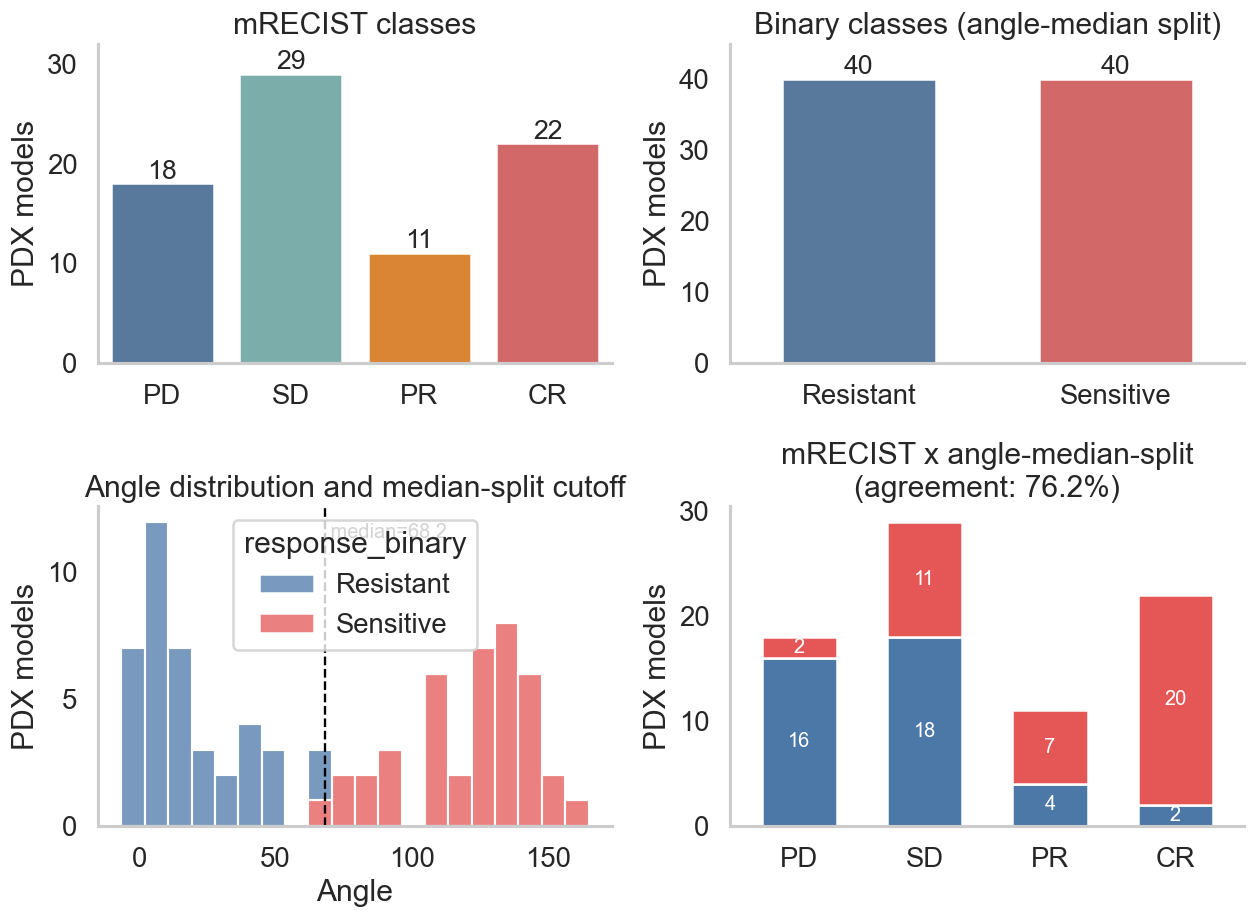

,model.id,mRECIST,angle,response_binary
0,NOTCH10,PR,24.952204,Resistant
1,REF024,PR,35.034703,Resistant
2,S18674,CR,43.546818,Resistant
3,S73230,CR,46.725173,Resistant
4,S44721,PR,49.658143,Resistant
5,S241417,PR,66.756904,Resistant
6,S44205,SD,69.696698,Sensitive
7,REF034,SD,70.657522,Sensitive
8,S71335,SD,88.056448,Sensitive
9,DCPTOB19,SD,106.370493,Sensitive


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(11, 8))

sns.countplot(
    data=metadata_df,
    x="mRECIST",
    order=MRECIST_ORDER,
    palette=PALETTE_MRECIST,
    ax=axes[0, 0],
)
for p in axes[0, 0].patches:
    height = p.get_height()
    axes[0, 0].annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=16)
axes[0, 0].set_title("mRECIST classes")
axes[0, 0].set_xlabel("")
axes[0, 0].set_ylabel("PDX models")
axes[0, 0].set_ylim(0, metadata_df["mRECIST"].value_counts().max() + 3)

sns.countplot(
    data=metadata_df,
    x="response_binary",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=axes[0, 1],
    width=0.6
)
for p in axes[0, 1].patches:
    height = p.get_height()
    axes[0, 1].annotate(f"{int(height)}", (p.get_x() + p.get_width() / 2., height),
                        ha='center', va='bottom', fontsize=16)
axes[0, 1].set_title("Binary classes (angle-median split)")
axes[0, 1].set_xlabel("")
axes[0, 1].set_ylabel("PDX models")
axes[0, 1].set_ylim(0, metadata_df["response_binary"].value_counts().max() + 5)

# Angle distribution with the median-split cutoff. The binary label is defined
# directly from this threshold, so the two groups separate perfectly by
# construction -- this panel illustrates the endpoint definition, it is not a
# hypothesis test (unlike the old mRECIST-based QC, angle-vs-response_binary
# has no informative p-value here).
angle_median = metadata_df["angle"].median()
sns.histplot(
    data=metadata_df,
    x="angle",
    hue="response_binary",
    hue_order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    multiple="stack",
    bins=20,
    ax=axes[1, 0],
)
axes[1, 0].axvline(angle_median, color="black", linestyle="--", linewidth=1.4)
axes[1, 0].text(angle_median, axes[1, 0].get_ylim()[1] * 0.95, f" median={angle_median:.1f}",
                 fontsize=12, va="top")
axes[1, 0].set_title("Angle distribution and median-split cutoff")
axes[1, 0].set_xlabel("Angle")
axes[1, 0].set_ylabel("PDX models")

# mRECIST x angle-median-split concordance -- how the clinical categories
# relate to the modeling endpoint (angle was chosen over mRECIST as the label
# source; see feature_sets.add_binary_response docstring for why).
concordance = (
    metadata_df.groupby(["mRECIST", "response_binary"]).size().unstack(fill_value=0)
    .reindex(MRECIST_ORDER)[RESPONSE_ORDER]
)
concordance.plot(
    kind="bar", stacked=True,
    color=[PALETTE_BINARY[c] for c in RESPONSE_ORDER],
    ax=axes[1, 1], width=0.6, legend=False,
)
for container in axes[1, 1].containers:
    axes[1, 1].bar_label(container, label_type="center", fontsize=12, color="white")

mrecist_collapsed = metadata_df["mRECIST"].map(
    {"PD": "Resistant", "SD": "Resistant", "PR": "Sensitive", "CR": "Sensitive"}
)
agreement = (metadata_df["response_binary"] == mrecist_collapsed).mean()
axes[1, 1].set_title(f"mRECIST x angle-median-split\n(agreement: {agreement:.1%})")
axes[1, 1].set_xlabel("")
axes[1, 1].set_ylabel("PDX models")
axes[1, 1].tick_params(axis="x", rotation=0)

for ax in axes.flatten():
    ax.grid(False)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("response_endpoint_qc")
plt.show()

response_qc_df

## Figure 2: Single-omics and Multi-omics Benchmark

In [5]:
plot_models = [
    ("single_omics", "rna_paired", "random_forest", "RNA only\nRandom forest"),
    ("single_omics", "cnv", "random_forest", "CNV only\nRandom forest"),
    ("single_omics", "mutation", "svm_rbf", "Mutation only\nSVM RBF"),
    ("early_fusion", "rna_cnv_mutation", "random_forest", "Early fusion\nRandom forest"),
    ("late_fusion_stacking", "rna_cnv_mutation", "stack_random_forest", "Late fusion\nRandom forest"),
]

rows = []
for analysis, omics, model, label in plot_models:
    sub = all_results_df[
        (all_results_df["analysis"] == analysis)
        & (all_results_df["omics"] == omics)
        & (all_results_df["model"] == model)
    ].copy()
    if sub.empty:
        print("Missing:", analysis, omics, model)
        continue
    sub["plot_label"] = label
    rows.append(sub)

benchmark_df = pd.concat(rows, ignore_index=True)
benchmark_df["plot_label"] = pd.Categorical(
    benchmark_df["plot_label"],
    categories=[x[3] for x in plot_models],
    ordered=True,
)

benchmark_summary_df = (
    benchmark_df
    .groupby("plot_label", observed=True)[["auroc", "auprc", "balanced_accuracy", "f1"]]
    .agg(["mean", "std"])
    .round(3)
)
benchmark_summary_df


auroc         auprc        balanced_accuracy  \
                              mean    std   mean    std              mean   
plot_label                                                                  
RNA only\nRandom forest      0.700  0.132  0.742  0.104             0.666   
CNV only\nRandom forest      0.559  0.195  0.652  0.154             0.550   
Mutation only\nSVM RBF       0.582  0.140  0.631  0.117             0.497   
Early fusion\nRandom forest  0.683  0.126  0.723  0.104             0.656   
Late fusion\nRandom forest   0.671  0.181  0.725  0.151             0.612   

                                       f1         
                               std   mean    std  
plot_label                                        
RNA only\nRandom forest      0.153  0.679  0.166  
CNV only\nRandom forest      0.153  0.571  0.173  
Mutation only\nSVM RBF       0.038  0.451  0.324  
Early fusion\nRandom forest  0.123  0.671  0.150  
Late fusion\nRandom forest   0.137  0.605  0.162

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_auroc.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_auroc.pdf


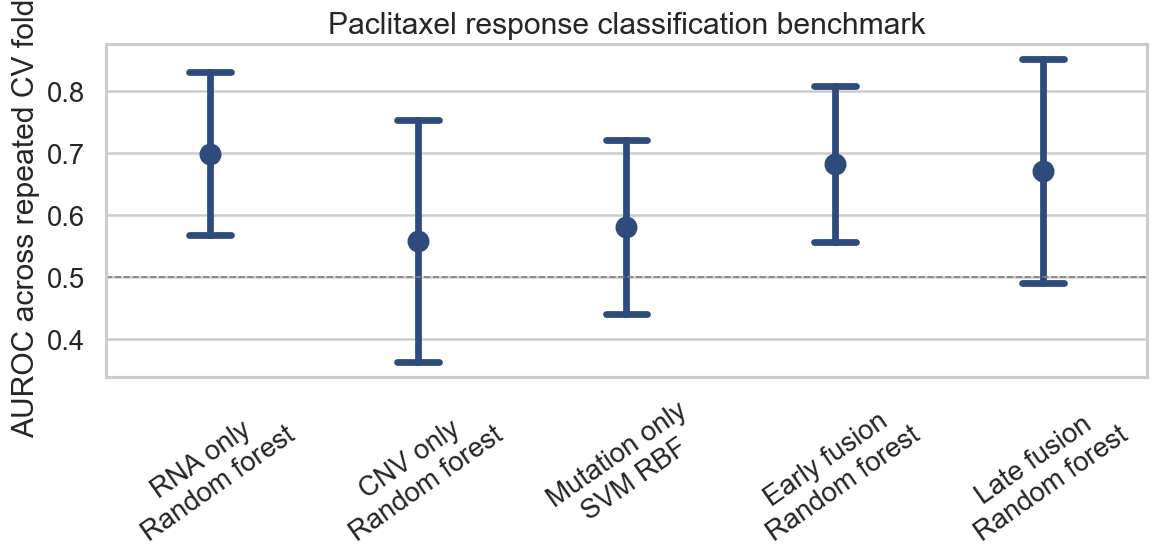

In [6]:
fig, ax = plt.subplots(figsize=(10, 5))
sns.pointplot(
    data=benchmark_df,
    x="plot_label",
    y="auroc",
    errorbar="sd",
    join=False,
    capsize=0.2,
    color="#2F4B7C",
    ax=ax,
)
ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_title("Paclitaxel response classification benchmark")
ax.set_xlabel("")
ax.set_ylabel("AUROC across repeated CV folds")
ax.tick_params(axis="x", rotation=35)
plt.tight_layout()
savefig("model_benchmark_auroc")
plt.show()

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_multi_metric.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/model_benchmark_multi_metric.pdf


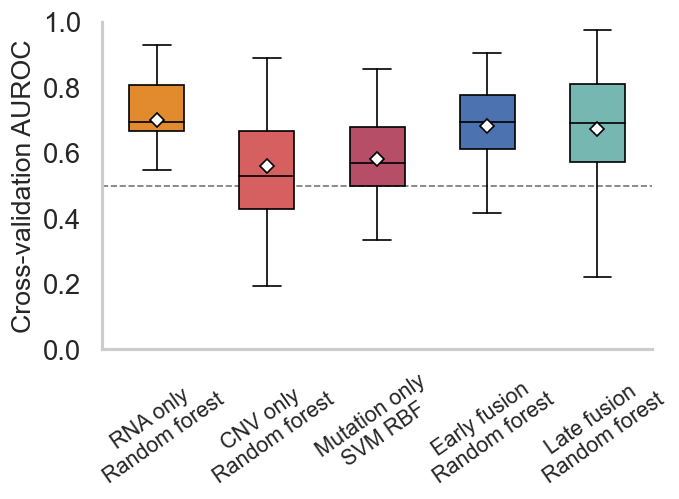

In [7]:
box_colors = {
    "RNA only\nRandom forest": "#E28A2E",
    "CNV only\nRandom forest": "#D65F5F",
    "Mutation only\nSVM RBF": "#B64E68",
    "Early fusion\nRandom forest": "#4C72B0",
    "Late fusion\nRandom forest": "#76B7B2",
}

plot_labels = list(benchmark_df["plot_label"].cat.categories)
box_data = [benchmark_df.loc[benchmark_df["plot_label"] == label, "auroc"].to_numpy() for label in plot_labels]
colors = [box_colors[label] for label in plot_labels]

fig, ax = plt.subplots(figsize=(6, 4.5))

ax.axhline(0.5, color="#777777", linestyle="--", linewidth=1, zorder=1)

bp = ax.boxplot(
    box_data,
    positions=np.arange(len(plot_labels)),
    widths=0.5,
    showfliers=False,
    showmeans=True,
    patch_artist=True,
    medianprops=dict(color="black"),
    meanprops=dict(marker="D", markerfacecolor="white", markeredgecolor="black", markersize=6),
    whiskerprops=dict(color="black"),
    capprops=dict(color="black"),
    boxprops=dict(color="black"),
)
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)

# for xpos, data in enumerate(box_data):
#     ax.text(xpos, min(data.max() + 0.03, 0.99), f"{data.mean():.2f}", ha="center", va="bottom", fontsize=13)

ax.set_xticks(np.arange(len(plot_labels)))
ax.set_xticklabels(plot_labels, fontsize=13)
ax.set_ylabel("Cross-validation AUROC", fontsize=16)
# ax.set_title("Model Performance", pad=12, fontsize=22)
ax.set_ylim(0, 1)
ax.tick_params(axis="x", labelsize=13, rotation=35)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)

plt.tight_layout()
savefig("model_benchmark_multi_metric")
plt.show()


## Figure 3: ROC and Precision-Recall Curves for Representative Models

Curves pool held-out predictions across repeated CV folds. Because each sample appears in multiple held-out folds across repeats, these curves are descriptive summaries of cross-validated predictions.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/roc_curves_representative_models.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/roc_curves_representative_models.pdf


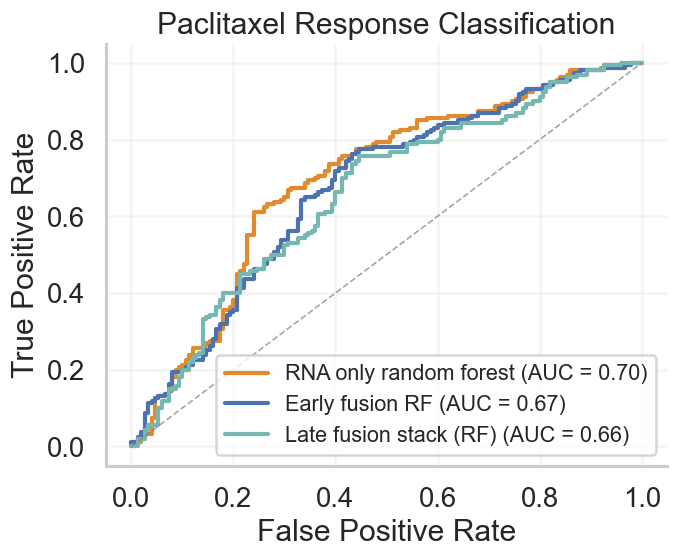

In [8]:
curve_models = [
    ("single_omics", "rna_paired", "random_forest", "RNA only random forest", "#E28A2E"),
    ("early_fusion", "rna_cnv_mutation", "random_forest", "Early fusion RF", "#4C72B0"),
    ("late_fusion_stacking", "rna_cnv_mutation", "stack_random_forest", "Late fusion stack (RF)", "#76B7B2"),
]

fig, ax = plt.subplots(figsize=(6, 5))

for analysis, omics, model, label, color in curve_models:
    try:
        sub = pooled_curve_data(all_predictions_df, model=model, analysis=analysis, omics=omics)
    except ValueError as err:
        print(err)
        continue

    fpr, tpr, _ = roc_curve(sub["y_true"], sub["y_score_sensitive"])
    roc_val = roc_auc_score(sub["y_true"], sub["y_score_sensitive"])
    ax.plot(fpr, tpr, linewidth=2.5, label=f"{label} (AUC = {roc_val:.2f})", color=color)

ax.plot([0, 1], [0, 1], color="gray", linewidth=1, linestyle="--", alpha=0.7)
ax.set_title("Paclitaxel Response Classification", fontsize=18)
ax.set_xlabel("False Positive Rate", fontsize=18)
ax.set_ylabel("True Positive Rate", fontsize=18)
ax.legend(loc="lower right", fontsize=13)
ax.grid(alpha=0.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()
savefig("roc_curves_representative_models")
plt.show()

## Figure 4: Prediction Score Distributions

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/early_fusion_rf_prediction_scores.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/early_fusion_rf_prediction_scores.pdf


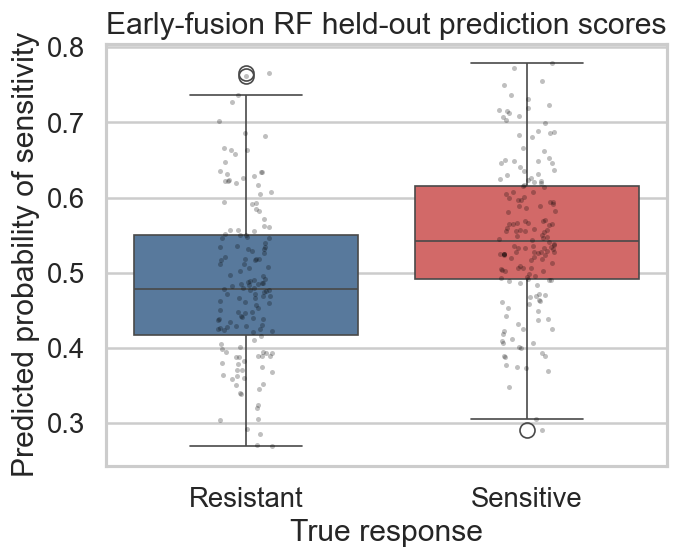

Mann-Whitney p: 1.5211624731307993e-07


In [9]:
best_pred_df = pooled_curve_data(
    all_predictions_df,
    model="random_forest",
    analysis="early_fusion",
    omics="rna_cnv_mutation",
).copy()
best_pred_df["true_response"] = best_pred_df["y_true_label"]

fig, ax = plt.subplots(figsize=(6, 5))
sns.boxplot(
    data=best_pred_df,
    x="true_response",
    y="y_score_sensitive",
    order=RESPONSE_ORDER,
    palette=PALETTE_BINARY,
    ax=ax,
)
sns.stripplot(
    data=best_pred_df,
    x="true_response",
    y="y_score_sensitive",
    order=RESPONSE_ORDER,
    color="black",
    alpha=0.25,
    size=3,
    ax=ax,
)
ax.set_title("Early-fusion RF held-out prediction scores")
ax.set_xlabel("True response")
ax.set_ylabel("Predicted probability of sensitivity")
plt.tight_layout()
savefig("early_fusion_rf_prediction_scores")
plt.show()

resistant = best_pred_df.loc[best_pred_df["true_response"] == "Resistant", "y_score_sensitive"]
sensitive = best_pred_df.loc[best_pred_df["true_response"] == "Sensitive", "y_score_sensitive"]
print("Mann-Whitney p:", mannwhitneyu(resistant, sensitive, alternative="two-sided").pvalue)

## Figure 5: RNA Feature Importance (Best Single-omics Model)

A single random forest is fit on the full `rna_all` cohort (all 67 models) using the same fold-safe feature-selection pipeline as the CV evaluation, purely to inspect which genes drive the model. This fit is not used for any performance metric -- scoring it on its own training data would be circular; the actual AUROC estimate is the cross-validated one from Figures 2-4.

saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_feature_importance_top25.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_feature_importance_top25.pdf


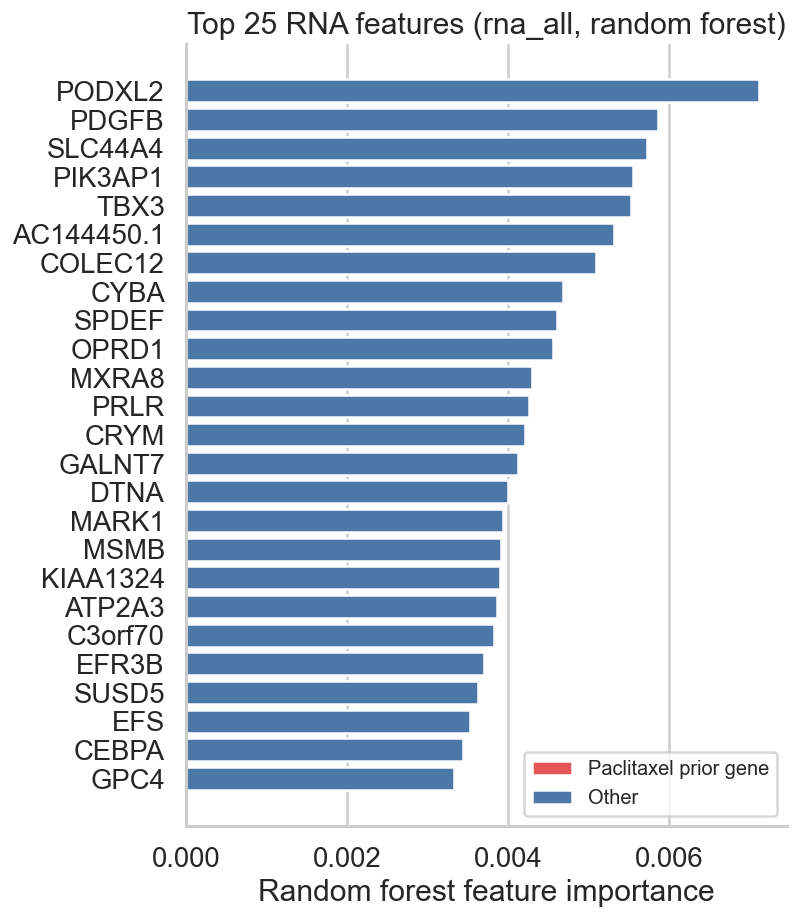

0/25 top features are paclitaxel-prior genes (prior list size=69, selected feature count=2055)


,gene,importance,is_pax_prior
0,PODXL2,0.007112,False
1,PDGFB,0.005860,False
2,SLC44A4,0.005728,False
3,PIK3AP1,0.005554,False
4,TBX3,0.005524,False
5,AC144450.1,0.005320,False
6,COLEC12,0.005090,False
7,CYBA,0.004689,False
8,SPDEF,0.004612,False
9,OPRD1,0.004564,False


In [10]:
X_rna_all, y_rna_all = split_x_class_y(rna_df)
rna_all_selected = select_features_by_omics(
    "rna_all", X_rna_all, prior_mode="pax", pax_genes=pax_genes, nest_genes=nest_genes
)
X_rna_all_selected = X_rna_all[rna_all_selected]

rf_importance_model = RandomForestClassifier(
    n_estimators=500,
    max_features="sqrt",
    class_weight="balanced",
    random_state=RANDOM_STATE,
    n_jobs=-1,
)
rf_importance_model.fit(X_rna_all_selected, y_rna_all)

importance_df = pd.DataFrame({
    "gene": rna_all_selected,
    "importance": rf_importance_model.feature_importances_,
})
importance_df["is_pax_prior"] = importance_df["gene"].isin(pax_genes)
importance_df = importance_df.sort_values("importance", ascending=False).reset_index(drop=True)

TOP_N = 25
top_df = importance_df.head(TOP_N).iloc[::-1]

fig, ax = plt.subplots(figsize=(7, 8))
bar_colors = top_df["is_pax_prior"].map({True: PALETTE_BINARY["Sensitive"], False: PALETTE_BINARY["Resistant"]})
ax.barh(top_df["gene"], top_df["importance"], color=bar_colors)
ax.set_xlabel("Random forest feature importance")
ax.set_title(f"Top {TOP_N} RNA features (rna_all, random forest)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False, axis="y")

legend_elements = [
    Patch(facecolor=PALETTE_BINARY["Sensitive"], label="Paclitaxel prior gene"),
    Patch(facecolor=PALETTE_BINARY["Resistant"], label="Other"),
]
ax.legend(handles=legend_elements, loc="lower right", fontsize=12)

plt.tight_layout()
savefig("rna_feature_importance_top25")
plt.show()

n_pax_in_top = int(top_df["is_pax_prior"].sum())
print(
    f"{n_pax_in_top}/{TOP_N} top features are paclitaxel-prior genes "
    f"(prior list size={len(pax_genes)}, selected feature count={len(rna_all_selected)})"
)

importance_df.to_csv(RESULTS_DIR / "rna_feature_importance.csv", index=False)
importance_df.head(TOP_N)

## Figure 6: RNA Pathway Enrichment (GSEA)

Every gene in the full `rna_all` matrix (all ~49k genes, not the ~2,000 features pre-filtered for classification) is ranked by a Welch's t-statistic comparing Sensitive vs Resistant models (angle-median split, n=67), then tested with pre-ranked GSEA against MSigDB Hallmark, KEGG, and GO Biological Process gene sets. Positive NES = enriched in Sensitive models; negative NES = enriched in Resistant models. This is a separate, complementary view to the single-gene importance panel in Figure 5 -- it asks whether the RNA signal aggregates into coherent biological pathways rather than isolated genes.

In [11]:
import gseapy as gp
from scipy import stats

GSEA_PERMUTATIONS = 5000
GSEA_MIN_SIZE = 15
GSEA_MAX_SIZE = 500
GSEA_FDR_THRESHOLD = 0.05
GSEA_TOP_PER_DIRECTION = 4
GSEA_SEED = 42

gsea_gene_set_libraries = {
    "GO Biological Process": "GO_Biological_Process_2023",
    "KEGG": "KEGG_2021_Human",
    "MSigDB Hallmark": "MSigDB_Hallmark_2020",
}

# Rank every gene in the full RNA matrix (not the pre-filtered classification
# feature set) by a Welch t-statistic between Sensitive and Resistant rna_all
# models. Positive statistic = higher expression in Sensitive models.
rna_expr_all = rna_df.drop(columns=[c for c in ["angle", "mRECIST", "response_binary", "response_binary_num"] if c in rna_df.columns])
sensitive_mask = rna_df["response_binary"] == "Sensitive"
resistant_mask = rna_df["response_binary"] == "Resistant"

gsea_test = stats.ttest_ind(
    rna_expr_all.loc[sensitive_mask].to_numpy(dtype=float),
    rna_expr_all.loc[resistant_mask].to_numpy(dtype=float),
    axis=0, equal_var=False, nan_policy="omit",
)
gsea_rank_table = pd.DataFrame({
    "Gene": rna_expr_all.columns,
    "ranking_statistic": gsea_test.statistic,
})
gsea_rank_table = (
    gsea_rank_table.replace([np.inf, -np.inf], np.nan)
    .dropna(subset=["ranking_statistic"])
    .sort_values("ranking_statistic", ascending=False)
    .reset_index(drop=True)
)
gsea_rank_table.to_csv(RESULTS_DIR / "rna_gsea_gene_ranking.csv", index=False)
print(
    f"Ranked {len(gsea_rank_table):,} genes "
    f"({int(sensitive_mask.sum())} Sensitive vs {int(resistant_mask.sum())} Resistant, rna_all)"
)

gsea_results = {}
for collection_label, library_name in gsea_gene_set_libraries.items():
    enrichment = gp.prerank(
        rnk=gsea_rank_table[["Gene", "ranking_statistic"]],
        gene_sets=library_name,
        min_size=GSEA_MIN_SIZE, max_size=GSEA_MAX_SIZE,
        permutation_num=GSEA_PERMUTATIONS,
        threads=4, seed=GSEA_SEED,
        outdir=None, no_plot=True, verbose=False,
    )
    result = enrichment.res2d.copy()
    result["NES"] = result["NES"].astype(float)
    result["FDR q-val"] = result["FDR q-val"].astype(float)
    result["Collection"] = collection_label
    result["Direction"] = np.where(result["NES"] > 0, "Sensitive", "Resistant")
    gsea_results[collection_label] = result
    output_name = collection_label.lower().replace(" ", "_")
    result.to_csv(RESULTS_DIR / f"rna_gsea_{output_name}.csv", index=False)

for collection_label, result in gsea_results.items():
    n_sig = (result["FDR q-val"] < GSEA_FDR_THRESHOLD).sum()
    print(f"{collection_label}: {n_sig}/{len(result)} gene sets significant at FDR < {GSEA_FDR_THRESHOLD}")

2026-07-28 16:41:47,534 [WARNING] Duplicated values found in preranked stats: 9.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


Ranked 49,348 genes (34 Sensitive vs 33 Resistant, rna_all)


2026-07-28 16:46:29,542 [WARNING] Duplicated values found in preranked stats: 9.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


2026-07-28 16:47:07,246 [WARNING] Duplicated values found in preranked stats: 9.28% of genes
The order of those genes will be arbitrary, which may produce unexpected results.


GO Biological Process: 310/2710 gene sets significant at FDR < 0.05
KEGG: 71/306 gene sets significant at FDR < 0.05
MSigDB Hallmark: 23/50 gene sets significant at FDR < 0.05


saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_pathways.png
saved /Users/guanqiaofeng/Documents/BHK/XevaDB/Manuscript_gitrepo/XevaDB_case_study/results/4_paclitaxel/figures/rna_gsea_pathways.pdf


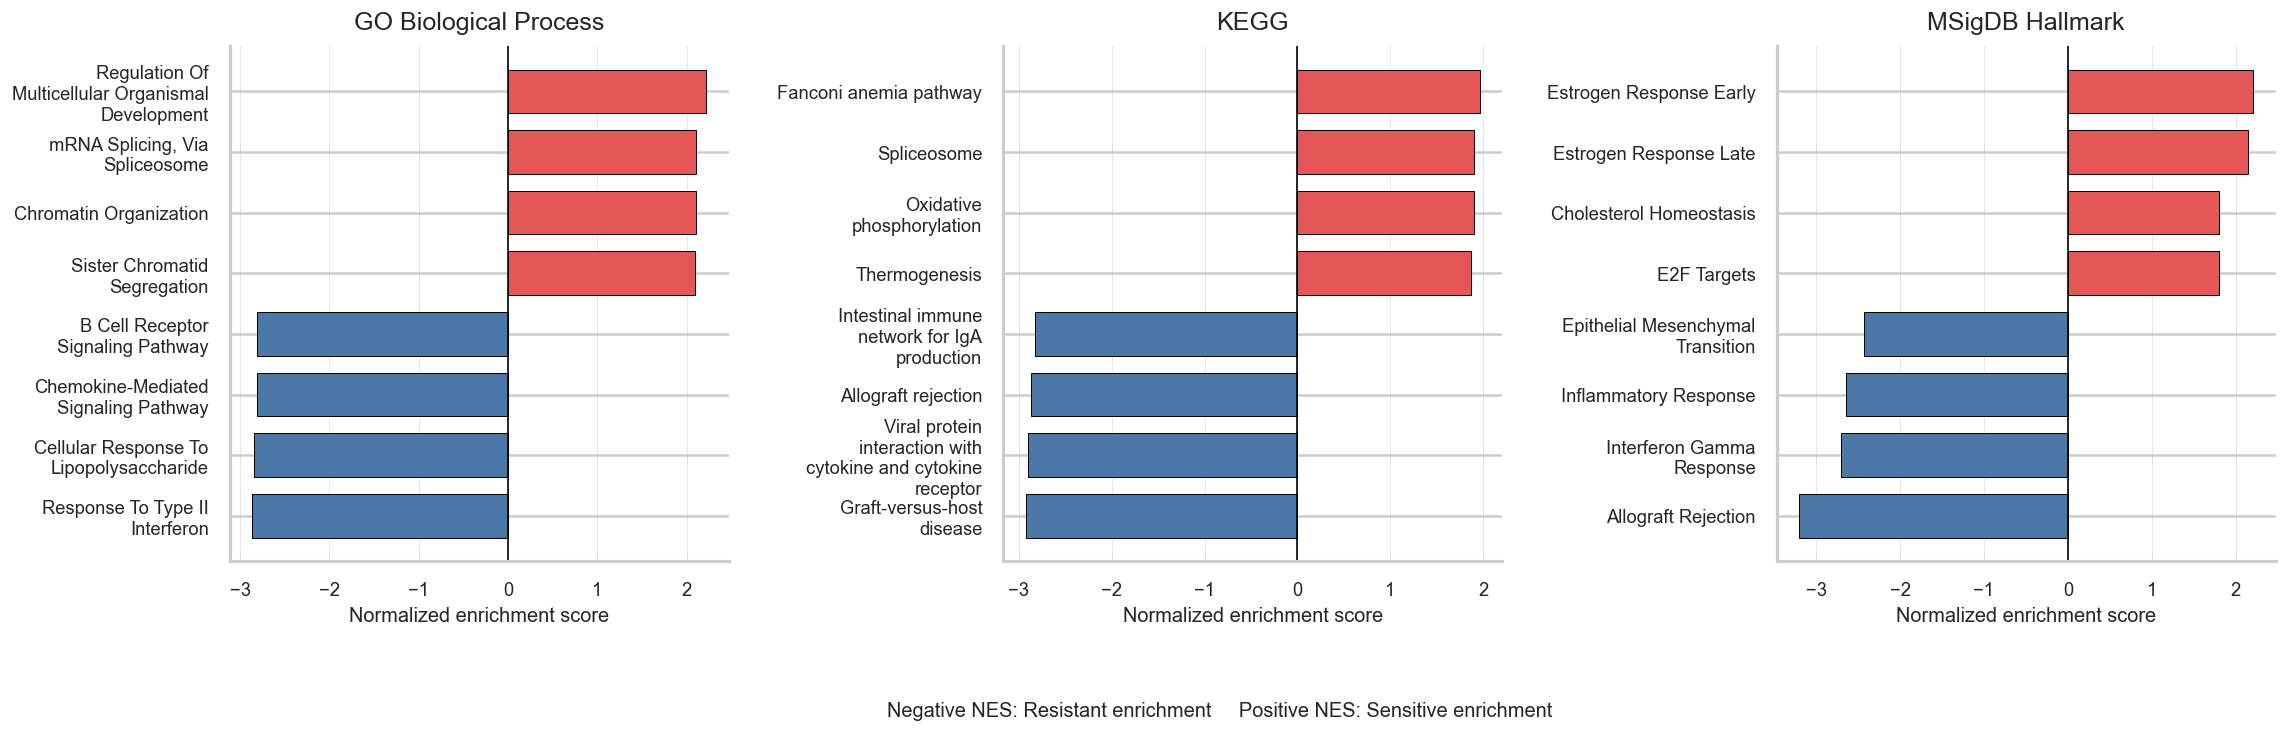

In [12]:
import textwrap


def select_pathways_for_plot(result):
    significant = result.loc[result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
    sensitive_top = (
        significant.loc[significant["NES"] > 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, False])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    resistant_top = (
        significant.loc[significant["NES"] < 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, True])
        .head(GSEA_TOP_PER_DIRECTION)
    )
    return pd.concat([resistant_top, sensitive_top]).sort_values("NES")


def format_pathway_name(term, collection_label):
    term = str(term).split(" (GO:")[0]
    if collection_label == "MSigDB Hallmark":
        term = term.replace("HALLMARK_", "").replace("_", " ").title()
    return "\n".join(textwrap.wrap(term, width=24))


fig, axes = plt.subplots(1, 3, figsize=(22, 6.5))
for ax, (collection_label, result) in zip(axes, gsea_results.items()):
    plot_data = select_pathways_for_plot(result)
    if plot_data.empty:
        ax.text(
            0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
        )
        ax.set_yticks([])
    else:
        labels = [format_pathway_name(term, collection_label) for term in plot_data["Term"]]
        colors = [
            PALETTE_BINARY["Sensitive"] if nes > 0 else PALETTE_BINARY["Resistant"]
            for nes in plot_data["NES"]
        ]
        ax.barh(labels, plot_data["NES"], color=colors, edgecolor="black", linewidth=0.6, height=0.72)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(collection_label, fontsize=15, pad=10)
    ax.set_xlabel("Normalized enrichment score", fontsize=12)
    ax.tick_params(axis="both", labelsize=11)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

fig.subplots_adjust(wspace=0.55, bottom=0.22)
fig.text(
    0.5, 0.02,
    "Negative NES: Resistant enrichment     Positive NES: Sensitive enrichment",
    ha="center", fontsize=12,
)
savefig("rna_gsea_pathways")
plt.show()

### Supplementary: top 6 pathways per direction

The main Figure 6 panel above shows the top 4 significant pathways per direction per collection. Some pathways discussed in the text (e.g., Hallmark's DNA Repair, TNF-alpha Signaling via NF-kB, and IL-6/JAK/STAT3 Signaling) are significant but fall just outside that top-4 cutoff. This panel reuses the same `gsea_results` (no GSEA recomputation) with `GSEA_TOP_PER_DIRECTION = 6` to show a fuller picture.

In [ ]:
GSEA_TOP_PER_DIRECTION_SUPP = 6

fig, axes = plt.subplots(1, 3, figsize=(22, 9.5))
for ax, (collection_label, result) in zip(axes, gsea_results.items()):
    significant = result.loc[result["FDR q-val"] < GSEA_FDR_THRESHOLD].copy()
    sensitive_top = (
        significant.loc[significant["NES"] > 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, False])
        .head(GSEA_TOP_PER_DIRECTION_SUPP)
    )
    resistant_top = (
        significant.loc[significant["NES"] < 0]
        .sort_values(["FDR q-val", "NES"], ascending=[True, True])
        .head(GSEA_TOP_PER_DIRECTION_SUPP)
    )
    plot_data = pd.concat([resistant_top, sensitive_top]).sort_values("NES")

    if plot_data.empty:
        ax.text(
            0.5, 0.5, f"No pathways at FDR < {GSEA_FDR_THRESHOLD:.2f}",
            transform=ax.transAxes, ha="center", va="center", fontsize=11,
        )
        ax.set_yticks([])
    else:
        labels = [format_pathway_name(term, collection_label) for term in plot_data["Term"]]
        colors = [
            PALETTE_BINARY["Sensitive"] if nes > 0 else PALETTE_BINARY["Resistant"]
            for nes in plot_data["NES"]
        ]
        ax.barh(labels, plot_data["NES"], color=colors, edgecolor="black", linewidth=0.6, height=0.72)
    ax.axvline(0, color="black", linewidth=1)
    ax.set_title(collection_label, fontsize=15, pad=10)
    ax.set_xlabel("Normalized enrichment score", fontsize=12)
    ax.tick_params(axis="both", labelsize=10.5)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.grid(axis="x", color="#D9D9D9", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)

fig.subplots_adjust(wspace=0.6, bottom=0.14)
fig.text(
    0.5, 0.015,
    "Negative NES: Resistant enrichment     Positive NES: Sensitive enrichment",
    ha="center", fontsize=12,
)
savefig("rna_gsea_pathways_top6")
plt.show()

## Export Manuscript Summary Tables

In [13]:
benchmark_summary_flat_df = (
    benchmark_df
    .groupby(["plot_label", "analysis", "omics", "model"], observed=True)
    .agg(
        auroc_mean=("auroc", "mean"),
        auroc_sd=("auroc", "std"),
        auprc_mean=("auprc", "mean"),
        auprc_sd=("auprc", "std"),
        balanced_accuracy_mean=("balanced_accuracy", "mean"),
        balanced_accuracy_sd=("balanced_accuracy", "std"),
        f1_mean=("f1", "mean"),
        sensitivity_mean=("sensitivity", "mean"),
        specificity_mean=("specificity", "mean"),
        n_features_mean=("n_features", "mean"),
    )
    .reset_index()
)
benchmark_summary_flat_df.to_csv(RESULTS_DIR / "manuscript_benchmark_summary.csv", index=False)
benchmark_summary_flat_df.round(3)

,plot_label,analysis,omics,model,auroc_mean,auroc_sd,auprc_mean,auprc_sd,balanced_accuracy_mean,balanced_accuracy_sd,f1_mean,sensitivity_mean,specificity_mean,n_features_mean
0,RNA only\nRandom forest,single_omics,rna_paired,random_forest,0.700,0.132,0.742,0.104,0.666,0.153,0.679,0.718,0.613,2055.52
1,CNV only\nRandom forest,single_omics,cnv,random_forest,0.559,0.195,0.652,0.154,0.550,0.153,0.571,0.607,0.493,491.60
2,Mutation only\nSVM RBF,single_omics,mutation,svm_rbf,0.582,0.140,0.631,0.117,0.497,0.038,0.451,0.640,0.353,426.60
3,Early fusion\nRandom forest,early_fusion,rna_cnv_mutation,random_forest,0.683,0.126,0.723,0.104,0.656,0.123,0.671,0.719,0.593,2973.72
4,Late fusion\nRandom forest,late_fusion_stacking,rna_cnv_mutation,stack_random_forest,0.671,0.181,0.725,0.151,0.612,0.137,0.605,0.610,0.613,3.00
